# Red Noise in Massive Stars

In [199]:
%matplotlib inline
#plt.style.use('/Users/mcantiello/.matplotlib/mesa.mplstyle')


import matplotlib.pyplot as plt
import mesa_reader as mr
import numpy as np
from pylab import *
from math import log10, pi
from matplotlib import rc
#rc('mathtext', default='regular')
import matplotlib as mpl
import matplotlib.tri as tri

import matplotlib.transforms as mtransforms
from matplotlib.ticker import MaxNLocator
from scipy import interpolate
from scipy.interpolate import griddata


from numpy import loadtxt
import pandas as pd 
from matplotlib.patches import Rectangle
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection
 
from Constants import Constants
c=Constants() 

# Define some colors
BLACK      = (0.00,0.00,0.00)
ORANGE     = (0.90,0.60,0.00)
SKY_BLUE   = (0.35,0.70,0.90)
BLUE_GREEN = (0.00,0.60,0.50)
YELLOW     = (0.95,0.90,0.25)
BLUE       = (0.00,0.45,0.70)
VERMILLION = (0.80,0.40,0.00)
RED_PURPLE = (0.80,0.60,0.70)

Constants defined...


In [200]:
####################################################
# Plt Options from Perna, Lazzati & Cantiello 2017 #
####################################################
plt.rcParams['figure.figsize'] = (6,7)
plt.rcParams['font.family'] = ['Times New Roman']
#plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'dejavusans'
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['mathtext.rm'] = 'serif'
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 20
plt.rcParams['ytick.labelsize'] = 20
plt.rcParams['axes.titlepad'] = 20 
plt.rcParams['legend.frameon'] = False
plt.rcParams['legend.fontsize'] = 14
plt.rcParams['font.size'] = 16
plt.rcParams['legend.borderpad'] = 0.2
plt.rc('legend', borderpad=0.2, markerscale=1., fancybox=False)
plt.rcParams['legend.labelspacing'] = 0.5
plt.rcParams['legend.handletextpad'] = 0.5
plt.rcParams['legend.handlelength'] = 1
plt.rcParams["legend.framealpha"] = 1.0
####################################################

In [201]:
rsun=6.9598e10
msun=1.9892e33
lsun=3.8418e33
tsun = 5777
G=6.67428e-8 

In [202]:
FIGURES='./figures/'

In [203]:
def find_zams(logl,loglh,model):
    zams=1
    while (loglh[zams] < 1.0*logl[zams]): 
     zams=zams+1
    return zams; 

def find_h(dh,center_h1,model):
    zams=1
    while (center_h1[zams] > (center_h1[1] - dh)): 
     zams=zams+1
    return zams; 
    
def find_tams(center_h1,model):
    tams=1
    while (center_h1[tams] > 0.05): 
     tams=tams+1
    return tams;    

def find_max(a,b,c,d):
    z= [0] * len(a)
    for i in range(0, len(a)):
      z[i]=max(a[i],b[i],c[i],d[i])   
    return z;

def binary(z):  
    for i in range(0, len(z)):
      if z[i] > 0:
         z[i] = 1
      else: 
         z[i] = 0
    return z;

def pbeta(p,b):    # Plasma Beta
    beta= 8*3.1415*p/(b**2.0)
    return beta;

def rossby(vcon,vroteq,hp,req): # Rossby number, defined as Prot/Pcon
    ross =(3.14*req/hp)*(vcon/veq)
    return ross; 
def beq(vcon,rho): # Calculate equipartition Bfield
    b=vcon*(4*3.14*rho)**0.5
    return b;
def char_freq(vcon,hp,req): # Rossby number, defined as Prot/Pcon
    ross =(3.14*req/hp)*(vcon/veq)
    return ross; 


logteff = r'$\log\, $T$_{\rm eff}/$K'

### From Velocity to Luminosity Fluctuations
This is from Kjeldsen and Bedding 1995, but including the effect of N cells (which somehow I don't think is included in their original formula. Surprisingly)

$\frac{d L}{L} \approx \frac{(V_{surf}/ m s^{-1})}{T_{eff}/5777 K} \, \frac{1}{\sqrt{N}}  $17.7 ppm

18ppm = 1.086 $\mu$mag

## Velocity fluctuations multiplied by $1 / \sqrt{N}$

## Mach Number 


# Subsurface Convection
## Comparing to Bowman et al. 2020 Data

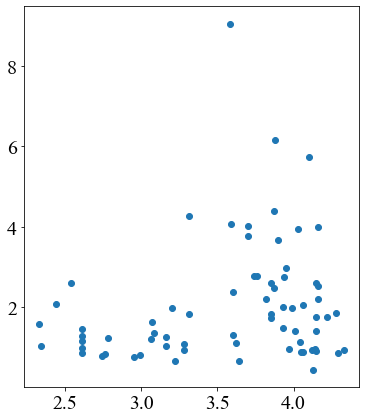

In [257]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02_CORE/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]

file='data_bowman_all.csv'
    
import pandas as pd 
df = pd.read_csv(file, sep=',')           # Read csv file into a panda dataframe


logl_data=df['logL']
logl_data=[float(item) for item in logl_data]

logt_data=df['logTeff']
logt_data=[float(item) for item in logt_data]

vmacro_data=df['vmacro']
vmacro_data=[float(item) for item in vmacro_data]


l=df['nuchar']                            # Read nuchar column 
nuchar=[i.split('±')[0] for i in l]       # Split elements (value  ±  error) and take value
nuchar_data = [float(item) for item in nuchar] # Turn into floats

l=df['alpha0']                            # Read nuchar column 
alpha0=[i.split('±')[0] for i in l]       # Split elements (value  ±  error) and take value
alpha0_data = [float(item) for item in alpha0] # Turn into floats




logl_data=np.array(logl_data)              # Turn lists into arrays 
logt_data=np.array(logt_data)
vmacro_data=np.array(vmacro_data)
nuchar_data=np.array(nuchar_data)
alpha0_data=np.array(alpha0_data)

#print(nuchar)
plt.scatter(logl_data,nuchar_data)

#print(df['nuchar'].str.extract('(\d+)'))

### Compare Macroturbulence Data to Convective Velocity in FeCZ (this is similar to Grassitelli et al. 2015)

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:89: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:90: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantie

-1.0 120.0
['$\\mathdefault{10}$', '$\\mathdefault{20}$', '$\\mathdefault{30}$', '$\\mathdefault{40}$', '$\\mathdefault{50}$', '$\\mathdefault{60}$', '$\\mathdefault{70}$', '$\\mathdefault{80}$', '$\\mathdefault{90}$', '$\\mathdefault{100}$', '$\\mathdefault{110}$', '$\\mathdefault{120}$']
['$\\mathdefault{120}$', '$\\mathdefault{100}$', '$\\mathdefault{80}$', '$\\mathdefault{60}$', '$\\mathdefault{40}$', '$\\mathdefault{20}$']


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/collections.py:922: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


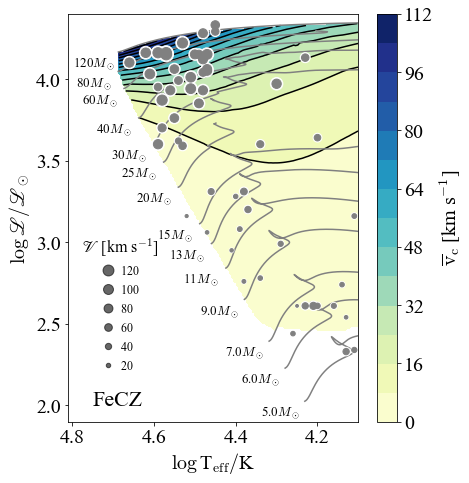

In [258]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
  #    tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_conv_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='YlGnBu',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ [km s$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
      #  tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
   
    ax.scatter(logt_data,logl_data,s=vmacro_data*1.8,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=vmacro_data,c='gray',zorder=3)
    print(min(vmacro_data),max(vmacro_data))
    
    
    handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
    print(labels)
    handles=handles[::-2]
    labels=labels[::-2]
    print(labels)
    legend2 = ax.legend(handles, labels,  title=r"$\mathscr{V}$ [km s$^{-1}$]",frameon=False, 
          fontsize=12,  bbox_to_anchor=(0.02,0.1),
          loc='lower left')
    
    ax.text(4.75,2.0,'FeCZ',fontsize=22)    
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_macroturbulence.pdf",bbox_inches='tight')

read_models(DIR,mods)


## Turbulent Pressure Plot

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:50: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:52: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:53: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:51: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:99: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:100: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcanti

['$\\mathdefault{10}$', '$\\mathdefault{20}$', '$\\mathdefault{30}$', '$\\mathdefault{40}$', '$\\mathdefault{50}$', '$\\mathdefault{60}$', '$\\mathdefault{70}$', '$\\mathdefault{80}$', '$\\mathdefault{90}$', '$\\mathdefault{100}$', '$\\mathdefault{110}$', '$\\mathdefault{120}$']
['$\\mathdefault{120}$', '$\\mathdefault{100}$', '$\\mathdefault{80}$', '$\\mathdefault{60}$', '$\\mathdefault{40}$', '$\\mathdefault{20}$']


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/collections.py:922: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


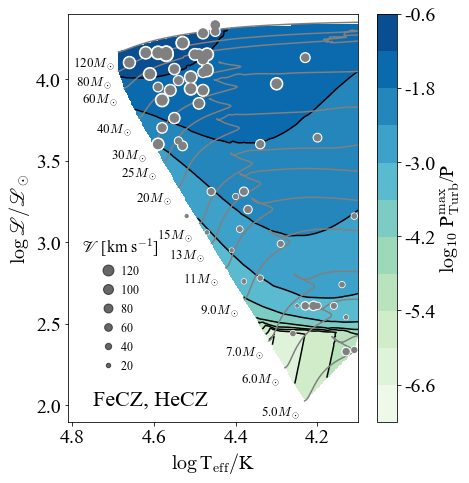

In [260]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/15140/Z0.02_CORE_F0/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]

ell_sun=(5777)**4.0/(274*100)  
plt.rcParams["contour.negative_linestyle"]='solid'
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver 
    
      FeCZ_p_turb_over_p=h.FeCZ_p_turb_over_p
      HeII_p_turb_over_p=h.HeII_p_turb_over_p
      HeI_p_turb_over_p=h.HeI_p_turb_over_p
      HI_p_turb_over_p=h.HI_p_turb_over_p  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      max_turb_pressure=np.maximum.reduce([FeCZ_p_turb_over_p,HeII_p_turb_over_p,HeI_p_turb_over_p,HI_p_turb_over_p,]) 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_turb_pressure[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
    z=np.log10(z)
    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 10, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 10, cmap='GnBu',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax,format='%.1f').ax.set_ylabel(r'$\log_{10}$ P$^{\rm max}_{\rm Turb}$/P')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
   
    ax.scatter(logt_data,logl_data,s=vmacro_data*1.8,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=vmacro_data,c='gray',zorder=3)
    #print(min(vmacro_data),max(vmacro_data))
    
    
    handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
    print(labels)
    handles=handles[::-2]
    labels=labels[::-2]
    print(labels)
    legend2 = ax.legend(handles, labels,  title=r"$\mathscr{V}$ [km s$^{-1}$]",frameon=False, 
          fontsize=12,  bbox_to_anchor=(0.02,0.1),
          loc='lower left')
    
    ax.text(4.75,2.0,'FeCZ, HeCZ',fontsize=22)    
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_turbulentpressure.pdf",bbox_inches='tight')

read_models(DIR,mods)


## Using predicted microturb surface velocities (Cantiello et al. 2009)

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:50: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:52: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:53: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:51: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:99: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:100: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcanti

['$\\mathdefault{10}$', '$\\mathdefault{20}$', '$\\mathdefault{30}$', '$\\mathdefault{40}$', '$\\mathdefault{50}$', '$\\mathdefault{60}$', '$\\mathdefault{70}$', '$\\mathdefault{80}$', '$\\mathdefault{90}$', '$\\mathdefault{100}$', '$\\mathdefault{110}$', '$\\mathdefault{120}$']
['$\\mathdefault{120}$', '$\\mathdefault{100}$', '$\\mathdefault{80}$', '$\\mathdefault{60}$', '$\\mathdefault{40}$', '$\\mathdefault{20}$']


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/collections.py:922: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


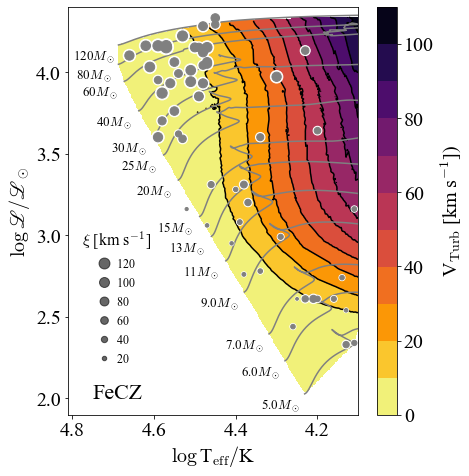

In [207]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/15140/Z0.02_CORE_F0/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]

ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver 
    
      FeCZ_p_turb_over_p=h.FeCZ_p_turb_over_p
      HeII_p_turb_over_p=h.HeII_p_turb_over_p
      HeI_p_turb_over_p=h.HeI_p_turb_over_p
      HI_p_turb_over_p=h.HI_p_turb_over_p  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_surf_velocity[zams:])
        
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 10, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 10, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'V$_{\rm Turb}$ [km s$^{-1}$])')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
   
    ax.scatter(logt_data,logl_data,s=vmacro_data*1.8,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=vmacro_data,c='gray',zorder=3)
    #print(min(vmacro_data),max(vmacro_data))
    
    
    handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
    print(labels)
    handles=handles[::-2]
    labels=labels[::-2]
    print(labels)
    legend2 = ax.legend(handles, labels,  title=r"$\xi$ [km s$^{-1}$]",frameon=False, 
          fontsize=12,  bbox_to_anchor=(0.02,0.1),
          loc='lower left')
    
    ax.text(4.75,2.0,'FeCZ',fontsize=22)    
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
 #   plt.savefig(FIGURES+"vc_FeCZ_turbulentpressure.pdf",bbox_inches='tight')

read_models(DIR,mods)


### Compare Frequency of Red Noise to Turnover Frequency in FeCZ

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:54: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:277: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:278: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


0.44918 9.0522
[9.0522   7.331596 5.610992 3.890388 2.169784]
[9, 7, 6, 4, '< 2']


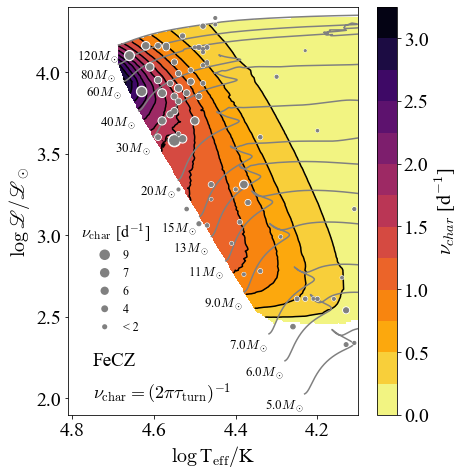

In [212]:

ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ # alpha Hp / vconv
      turnover_HeII=h.turnover_HeII  
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
    #  tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      z.append(turnover_FeCZ[zams:]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
    z=z/1.6 # Correct for Mixing Length Alpha (we calculate turnover as alpha H / vel)
    
    z=(1/(z*2*3.14/86400))  # in nu=(2\ pi Tau)^-1   in Bowman et al.      (d^-1 86400_
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ [d$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.05
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
      #  tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
 
    ### SCATTER PLOT
    
    norm_factor = 10
    ax.scatter(logt_data,logl_data,s=nuchar_data*(norm_factor*1.8),c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=nuchar_data*norm_factor,c='gray',zorder=3,norm=True)
    
    
    
    n_points = 5 # Select how many markers in legend
    vmax=max(nuchar_data)
    vmin=min(nuchar_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
   # l6 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.015,0.18) ,
          loc='lower left', title=r"$\nu_{\rm char}$ [d$^{-1}$]", markerscale=3.5) # Not sure why 3.5...  # bbox_to_anchor=(0.04,0.13)
    
   #######
    
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'$\nu_{\rm char} = (2 \pi \tau_{\rm turn})^{-1}$',fontsize=18)


    #  ax.text(4.6,2.0,r'$\nu_{\rm char} = (2 \pi \tau_{\rm turn})^{-1}$ ',fontsize=14) # 
 
    
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.81,4.1])
    ax.set_ylim([1.9,4.4])
    
#    plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_FeCZ_data.pdf",bbox_inches='tight')

    
read_models(DIR,mods)

### With no datapoints 

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:54: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:277: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:278: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


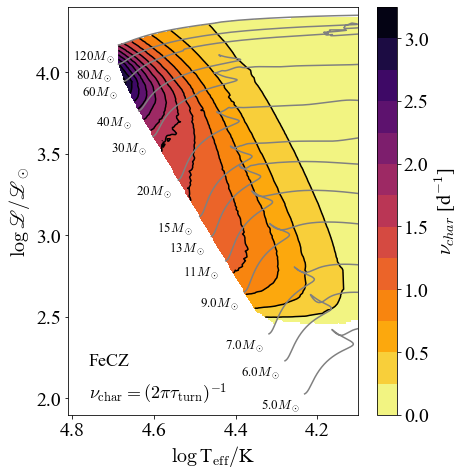

In [213]:

ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
     # tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      z.append(turnover_FeCZ[zams:]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
    z=z/1.6 # Correct for Mixing Length Alpha (we calculate turnover as alpha H / vel)
    
    z=(1/(z*2*3.14/86400))  # in nu=(2\ pi Tau)^-1   in Bowman et al.      (d^-1 86400_
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ [d$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
       # tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.text(4.76,2.0,r'$\nu_{\rm char} = (2 \pi \tau_{\rm turn})^{-1}$ ',fontsize=18) # 
    ax.text(4.76,2.2,'FeCZ',fontsize=18)
   # ax.scatter(logt_data,logl_data,s=nuchar_data*18,c='white',zorder=3)
   # ax.scatter(logt_data,logl_data,s=nuchar_data*10,c='gray',zorder=3)
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.81,4.1])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_FeCZ.pdf",bbox_inches='tight')

    
read_models(DIR,mods)

## Compare Photometric Amplitude to Convective velocities in FeCZ

### FeCZ Flux/Stellar Flux vs Photometric Amplitude
$\frac{dL}{L}\propto \frac{{\rm F}_{\rm c}}{\rm F_{*}}$

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:48: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:49: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:47: RuntimeWarning: invalid value encountered in true_divide


6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


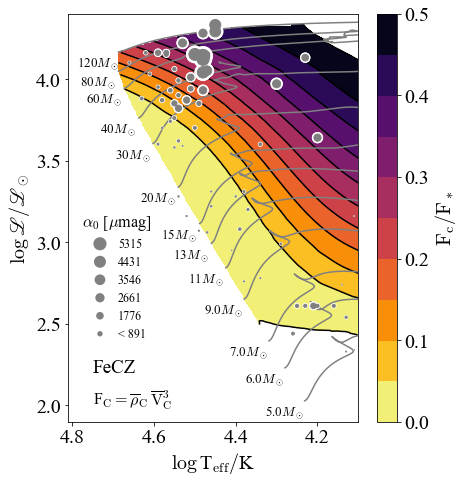

In [214]:
from matplotlib.ticker import *
import matplotlib.ticker as ticker
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from matplotlib.patches import Ellipse
from matplotlib.ticker import ScalarFormatter 

ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   
      flux=h.FeCZ_Fc_max  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
     # tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=z**0.5


    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    maxf=max(z)
    levels=np.arange(0.05,maxf,0.05)
    levels = insert(levels,0, 0.0001)
    
    ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
   
    cbar = fig.colorbar(cntr1, ax=ax)
    cbar.ax.set_ylabel(r'${\rm F}_{\rm c}/{\rm F}_*$')
    
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.1f'))
    plt.gca().invert_xaxis()
    
   
    dt = 0.05
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
       # tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm C} = \overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
     ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
#    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"flux_FeCZ_rednoise.pdf",bbox_inches='tight')

hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120] 
read_models(DIR,mods)


In [215]:
levels=np.arange(0.05,0.7,0.05)
print(levels)

levels = insert(levels,0, 0.001) 
print(levels) 

[0.05 0.1  0.15 0.2  0.25 0.3  0.35 0.4  0.45 0.5  0.55 0.6  0.65]
[0.001 0.05  0.1   0.15  0.2   0.25  0.3   0.35  0.4   0.45  0.5   0.55
 0.6   0.65 ]


### FeCZ Flux/Stellar Flux vs Photometric Amplitude
$\frac{dL}{L}\propto \frac{{\rm F}_{\rm c}\, {\rm M}_{\rm c}}{\rm F_{*}}$


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide


6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


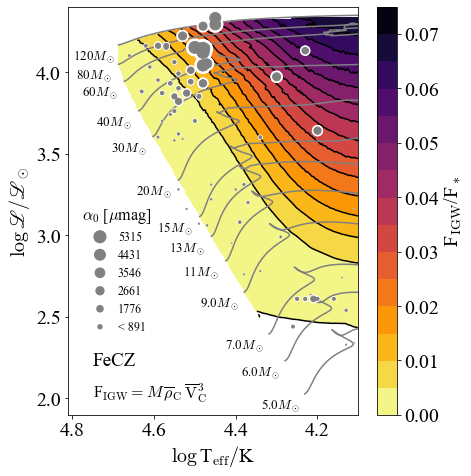

In [219]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
    
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*
      #flux=flux**0.5  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
    #  tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
   
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    #levels=np.arange(0.05,0.7,0.05)
    #levels = insert(levels,0, 0.0000001)
    
    
    maxf=max(z)
    levels=np.arange(0.005,0.08,0.005)
    levels = insert(levels,0, 0.000001)
    
    ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    
    
    
    #ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    #ax.contour(xi, yi, zi, 12, colors='k') # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r') #cmap="YlOrRd")
    
    
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'F$_{\rm IGW}$/F$_*$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
       # tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
    
     ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
#    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"flux_FeCZ_mach_rednoise.pdf",bbox_inches='tight')

        
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120]
read_models(DIR,mods)


## Daniel: Wave amplitude scales as square root of flux in IGWs
$\frac{dL}{L}\propto \sqrt{\frac{{\rm F}_{\rm c}\, {\rm M}_{\rm c}}{\rm F_{*}}}$


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide


6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


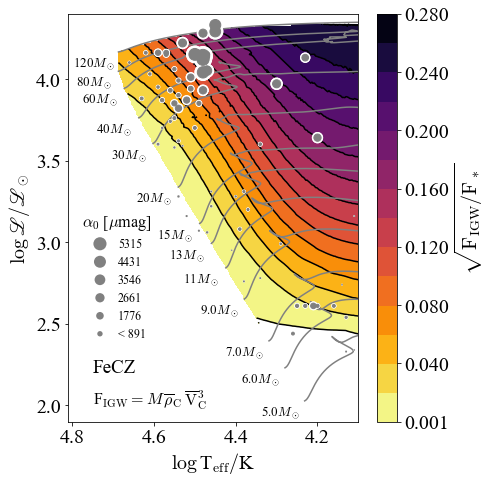

In [220]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
    
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*
      #flux=flux**0.5  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=z**0.5
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    #levels=np.arange(0.05,0.7,0.05)
    #levels = insert(levels,0, 0.0000001)
    
    
    levels=np.arange(0.02,0.30,0.02)
    levels = insert(levels,0, 0.001)
    
    ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    
    
    
    #ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    #ax.contour(xi, yi, zi, 12, colors='k') # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r') #cmap="YlOrRd")
    
    
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{{\rm F}_{\rm IGW}/{\rm F}_*}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
    
     ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
#    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"_sqrt_flux_FeCZ_mach_rednoise.pdf",bbox_inches='tight')

        
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120]
read_models(DIR,mods)


### With no data

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide


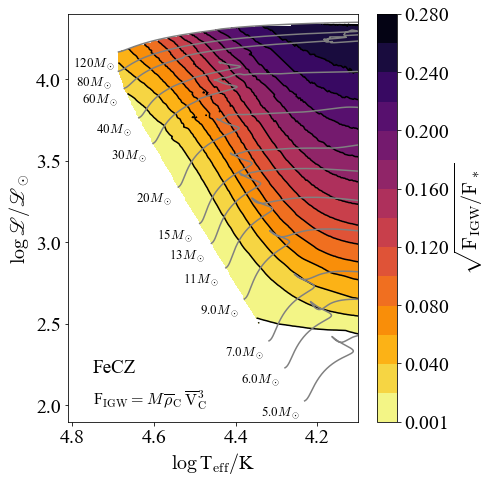

In [221]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*.  It is Max(Fc/F_*)*Mach 
      flux=flux**0.5  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
  #    tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    # z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    levels=np.arange(0.02,0.30,0.02)
    levels = insert(levels,0, 0.001)
    ax.contour(xi, yi, zi, 14, colors='k',levels=levels)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    
     #levels=np.arange(0.05,0.7,0.05)
    #levels = insert(levels,0, 0.0000001)
    #ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    #ax.contour(xi, yi, zi, 12, colors='k') # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r') #cmap="YlOrRd")
    
    
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{{\rm F}_{\rm IGW}/{\rm F}_*}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
   #     tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
 #   plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"sqrt_flux_FeCZ_mach_rednoise_nodata.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


## Number of Convective Cells 

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:277: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:278: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


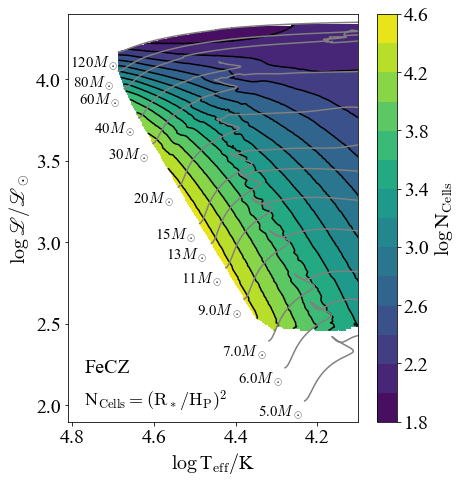

In [222]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      logR= h.log_R  
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      ncells=((10**logR)/(FeCZ_hp_aver/rsun))**2.0
      
      ncells=np.log10(ncells)  
    
      
        
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      
      zams=find_zams(logl,loglh,model)
   #   tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(ncells[zams:])
            

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    # z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    #levels=np.arange(0.02,0.30,0.02)
    #levels = insert(levels,0, 0.0000001)
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='viridis') #cmap="YlOrRd") inferno_r
    
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\log \, $N$_{\rm Cells}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
   #     tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=15) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.77,2.2,'FeCZ',fontsize=20)    
    ax.text(4.77,2.0,r'N$_{\rm Cells} = ({\rm R}_*/{\rm H}_{\rm P})^2$',fontsize=18)
    
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
   # plt.title(r'FeCZ Convective Cells')
    plt.savefig(FIGURES+"ncells_fecz.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


## IGW Relative Flux weighted by $\sqrt{N}$ 

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:55: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide


0.0 4.689823259320196
[0.         0.33498738 0.66997475 1.00496213 1.3399495  1.67493688
 2.00992425 2.34491163 2.67989901 3.01488638 3.34987376 3.68486113
 4.01984851 4.35483588]
6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


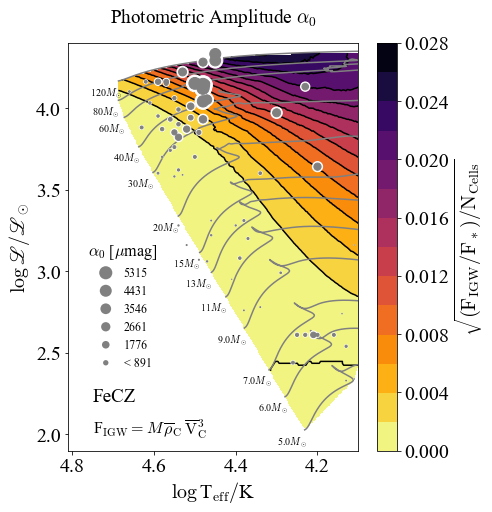

In [225]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff  
      logR= h.log_R  
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 # Here we're using average values across the convective zone ...
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*                   # ... but we multiply by the average Mach number at the top of the convection zone. 
      flux=flux**0.5  
    
      # DIVIDE by sqrt(Ncells)
      ncells=((10**logR)/(FeCZ_hp_aver/rsun))**2.0
      flux = flux / (ncells)**0.5  
      # 
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    n_levels = 14
    vmin=min(z)
    vmax=max(x)
    delta = (vmax-vmin)/n_levels
    print(vmin,vmax)
    levels=np.arange(vmin,vmax,delta)
    print(levels)
    #levels = insert(levels,0, 0.002)
    ax.contour(xi, yi, zi, n_levels, colors='k') # ,levels=levels
    cntr1 = ax.contourf(xi, yi, zi,n_levels, cmap='inferno_r') #cmap="YlOrRd") #,levels=levels
    
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{({\rm F}_{\rm IGW}/{\rm F}_*)/{\rm N}_{\rm Cells}}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
   
    
    ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.04,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16) 
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"sqrt_flux_FeCZ_mach_rednoise_weighted.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


### Show in $\mu$mag and adjust range

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:55: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide


0.0 4.689823259320196
[0.         0.33498738 0.66997475 1.00496213 1.3399495  1.67493688
 2.00992425 2.34491163 2.67989901 3.01488638 3.34987376 3.68486113
 4.01984851 4.35483588]
6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


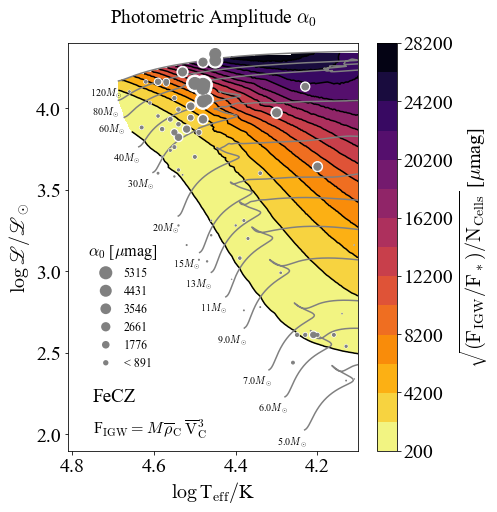

In [227]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff  
      logR= h.log_R  
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*
      flux=flux**0.5  
    
      # DIVIDE by sqrt(Ncells)
      ncells=((10**logR)/(FeCZ_hp_aver/rsun))**2.0
      flux = flux / (ncells)**0.5  
      # 
      
      # Transform to mag
      flux = 1+flux
      flux = 2.5*np.log10(flux)
  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))*1e6 #  /6 # (in mumag) # 6 is to account for alpha mlt 1.6 -> 1.0 ((1.5^3)^3)^0.5~6
  
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    n_levels = 14
    vmin=min(z)
    vmax=max(x)
    delta = (vmax-vmin)/n_levels
    print(vmin,vmax)
    levels=np.arange(vmin,vmax,delta)
    print(levels)
    
    levels= np.arange(0.0002,0.029,0.002)
    levels=levels*1e6

    #levels = insert(levels,0, 0.002)
    #ax.contour(xi, yi, zi, n_levels, colors='k') # ,levels=levels
    #cntr1 = ax.contourf(xi, yi, zi,n_levels, cmap='inferno_r') #cmap="YlOrRd") #,levels=levels
    ax.contour(xi, yi, zi, colors='k',levels=levels) # ,levels=levels
    cntr1 = ax.contourf(xi, yi, zi, cmap='inferno_r',levels=levels) #cmap="YlOrRd") #,levels=levels
    
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{({\rm F}_{\rm IGW}/{\rm F}_*)/{\rm N}_{\rm Cells}}$ [$\mu$mag]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
   
    
    ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.04,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16) 
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"sqrt_flux_FeCZ_mach_rednoise_weighted_mag.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


Notice alpha mlt uncertain by a factor 2. $V_c \propto \alpha^3$, so convective flux by a factor 8^3. And luminosity fluctuations by a factor of $\sqrt{8^3} \sim 20$ or so. Simulations suggest lower values of alpha (using 1.6 but 1 more likely, so in the right direction with explaining data). It looks like a factor of ~6 would brings things in nice agreement. This corresponds to $\alpha$ 1.6 -> 1.0. A nice indirect calibration. 


Dziembowski: two terms. Temperature perturbation >> Radial velocity perturbation 
Radial group velocity * energy density = Wave flux 1/sqrt(rho)
 


### Compare Photometric Amplitude to Surface velocities from FeCZ (assuming IGWs)

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:76: UserWarning: The following kwargs were not used by contour: 'setlims'


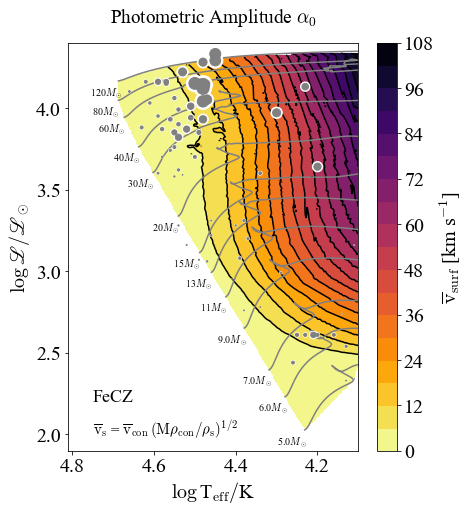

In [228]:
ell_sun=(5777)**4.0/(274*100)  


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_surf_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 18, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 18, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm surf}$ [km s$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.75,2.0,r'$\overline{\rm v}_{\rm s}$ = $\overline{\rm v}_{\rm con} \, (M \rho_{\rm con}/\rho_{\rm s})^{1/2}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"vsurf_FeCZ_data.pdf",bbox_inches='tight')


read_models(DIR,mods)


### Surface Velocity Fluctuations Weighted by Cell Number vs Amplitude Photometric Fluctuations

In [ ]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver 
      stellar_radius=10**h.log_R  
      n_cells=(stellar_radius*rsun/FeCZ_hp_aver)**2.0  
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      
      max_surf_velocity=max_surf_velocity/(n_cells)**0.5 
    
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      alpha_mlt=1.6
      vc=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vc=vc/(n_cells)**0.5 
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_surf_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 18, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 18, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm surf} \times 1/\sqrt{\rm N_{\rm cc}}$ (km s$^{-1}$)')
    plt.gca().invert_xaxis()
    
   
    dt = 0.03
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=10) # ,verticalalignment='center',rotation='vertical',  
        
        
    ax.text(4.75,2.0,r'$\overline{\rm v}_{\rm s}$ = $\overline{\rm v}_{\rm con} \, (M \rho_{\rm con}/\rho_{\rm s}/{\rm N}_{\rm cc})^{1/2}}$',fontsize=15)
    ax.text(4.75,2.2,'FeCZ',fontsize=18)
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"vsurf_ncells_FeCZ_data.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


# Now let's compare with Core Convection properties

In [229]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02_CORE_F0/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]

# Used for Spectroscopic HRD 
ell_sun=(5777)**4.0/(274*100)  


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:35: RuntimeWarning: invalid value encountered in true_divide


0.44918 9.0522
[9.0522   7.331596 5.610992 3.890388 2.169784]
[9, 7, 6, 4, '< 2']


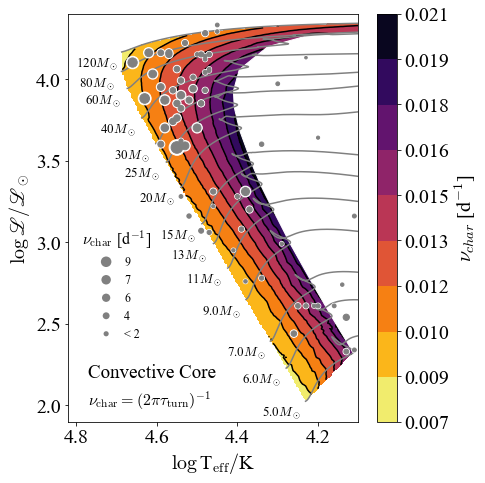

In [230]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      turnover_core=h.turnover_core
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
      v_aver_ahp_core = h.v_aver_ahp_core   # Values calculated in the top alpha_mlt * Hp of the core
      hp_core_top = h.hp_core_top  
      turnover_core_hp =  hp_core_top / v_aver_ahp_core
      #print(turnover_core_hp/86400)
        
        
      flux=rho_aver_core*v_aver_core**3.0
      #print(turnover_core)
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(ell[zams:tams])
      z.append(turnover_core_hp[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(1/(z*2*3.14/86400))  # in d^-1 86400
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 10, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 10, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    
    
    cbar = fig.colorbar(cntr1, ax=ax)
    cbar.ax.set_ylabel(r'$\nu_{char}$ [d$^{-1}$]')
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.3f'))
    

    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    mask=[]
    for i in hrdlines:
        
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 
    
    
    
    ### SCATTER PLOT
    
    norm_factor = 15
     
    
    ax.scatter(logt_data,logl_data,s=nuchar_data*(norm_factor*1.8),c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=nuchar_data*norm_factor,c='gray',zorder=3)
    
    
    n_points = 5 # Select how many markers in legend
    vmax=max(nuchar_data)
    vmin=min(nuchar_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
   # l6 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18) ,
          loc='lower left', title=r"$\nu_{\rm char}$ [d$^{-1}$]", markerscale=3.5) # Not sure why 3.5...  # bbox_to_anchor=(0.04,0.13)
    
   #######
    
    
    
 
    ax.text(4.77,2.17,'Convective Core',fontsize=19)    
    ax.text(4.77,2.0,r'$\nu_{\rm char} = (2 \pi \tau_{\rm turn})^{-1}$',fontsize=16)

    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')

    ax.set_xlim([4.82,4.1])
    ax.set_ylim([1.9,4.4])
    
  #  plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_core_data_days.pdf",bbox_inches='tight')

        

read_models(DIR,mods)

### In $\mu$Hz

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:37: RuntimeWarning: invalid value encountered in true_divide


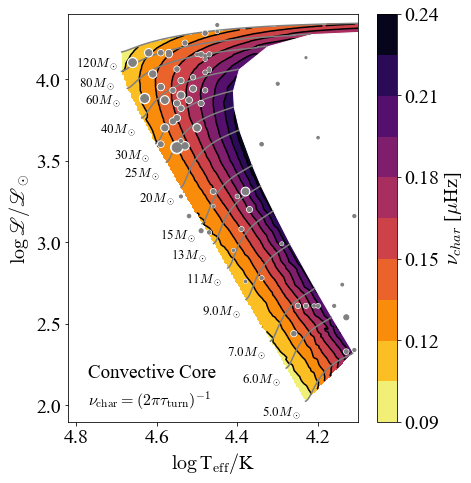

In [231]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      turnover_core=h.turnover_core
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
    
      v_aver_ahp_core = h.v_aver_ahp_core   # Values calculated in the top alpha_mlt * Hp of the core
      hp_core_top = h.hp_core_top  
      turnover_core_hp =  hp_core_top / v_aver_ahp_core
        
      hz=1/(2*3.14*turnover_core_hp) # To match definition of Bowman et al. 
      muHz=hz*1e6                     # (alpha= 1.6 ito account for alpha_mixing length, since we calculated turnover timescales as alpha*<Hp>/<vconv> 
      flux=rho_aver_core*v_aver_core**3.0
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:tams])
      y.append(ell[zams:tams])
      z.append(muHz[zams:tams]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
   
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 10, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 10, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ [$\mu$Hz]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    mask=[]
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 


 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
   
    ax.scatter(logt_data,logl_data,s=nuchar_data*18,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=nuchar_data*10,c='gray',zorder=3)
   

   
 
    
 
    ax.text(4.77,2.17,'Convective Core',fontsize=19)    
    ax.text(4.77,2.0,r'$\nu_{\rm char} = (2 \pi \tau_{\rm turn})^{-1}$',fontsize=16)

    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')

    ax.set_xlim([4.82,4.1])
    ax.set_ylim([1.9,4.4])
    
    
 #   plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_core_data_hz.pdf",bbox_inches='tight')

 
read_models(DIR,mods)





## Relative Flux of IGWs from the Convective Core

In [232]:
print('matplotlib: {}'.format(matplotlib.__version__))

matplotlib: 3.3.3


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:108: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:109: UserWarning: The following kwargs were not used by contour: 'setlims'


6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


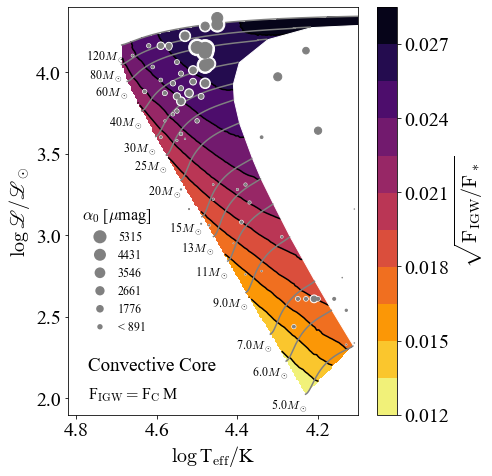

In [233]:
ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
        
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
      
      rho_aver_ahp_core=h.rho_aver_ahp_core
      v_aver_ahp_core=h.v_aver_ahp_core  
      mach_aver_ahp_core=h.mach_aver_ahp_core
      
      radius=10**h.log_R 
      stellar_flux= logl*lsun/(4*3.14*(radius*rsun)**2.0)
        
      flux_ahp=rho_aver_ahp_core*v_aver_ahp_core**3.0  # Flux in the top hp of the convective core
      # Divide by the total stellar flux (this shoul be pretty much the Mach number. Check)
      flux_IGW_ahp=flux_ahp*mach_aver_ahp_core/stellar_flux    # Assume IGWs are mostly driven in the top Hp
        
      flux_average=rho_aver_core*v_aver_core**3.0     # Average Flux in the convective core 
      flux_IGW_average=flux_average*mach_aver_ahp_core 
        
      v_aver_core=v_aver_core 
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:tams])
      y.append(ell[zams:tams])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(mach_aver_ahp_core[zams:tams])
      #flux_IGW_ahp[tams:]=1  
      #z.append(flux_IGW_ahp[tams:])  
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=z**0.5 
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 10, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 10, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{{\rm F}_{\rm IGW}/{\rm F}_*}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.04
    dl = -0.09
    
    mask=[]
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=12) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 
    
    ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    ax.text(4.77,2.17,'Convective Core',fontsize=19)    
    ax.text(4.77,2.0,r'F$_{\rm IGW} = $F$_{\rm C}\, $M ',fontsize=16)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
   # ax.text(4.77,2.13,'Convective Core',fontsize=18)    
   # ax.text(4.77,2.0,r'F$_{\rm IGW} = $F$_{\rm C}\, $M ',fontsize=17)
    
    ax.set_xlim([4.82,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
 #   plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"relative_flux_IGW_ahp_core_rednoise_data.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


### With F_0

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:63: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:70: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplo

0.025382638543847966 inf
6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


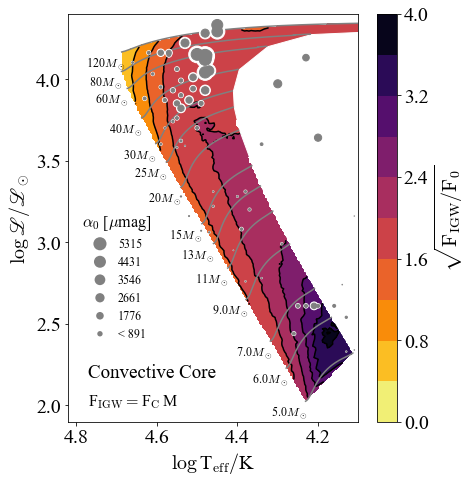

In [234]:
ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
        
      # Calculate F0  
      F0=h.F0_div_omega_c
      #sel = ((N2 < 0) & (R < 0.2 * R[0]))
      #N2_conv_avg = -np.sum(N2[sel] * dR[sel]) / np.sum(dR[sel])  
    
      
      
    
      lstar=lsun*10**logl  
      rstar=rsun*10**h.log_R  
      fstar = lstar/(4*pi*rstar**2.0)  
        
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
      
      rho_aver_ahp_core=h.rho_aver_ahp_core
      v_aver_ahp_core=h.v_aver_ahp_core  
      mach_aver_ahp_core=h.mach_aver_ahp_core
      turnover_core = h.turnover_core 
      F0=(2.0*3.1415)*F0*(1/(turnover_core))**2.0  # Multiply by 2pi to get N into angular frequency (since omega is angular frequency)
      #F0=((2.0*3.1415)**2.0)*F0*(1/(turnover_core))**2.0  # Multiply by 2pi to get N into angular frequency (since omega is angular frequency)

      #where_are_NaNs = isnan(F0)
      #F0[where_are_NaNs] = 0  
        
      flux_ahp=rho_aver_ahp_core*v_aver_ahp_core**3.0  # Flux in the top hp of the convective core
      flux_IGW_ahp=flux_ahp*mach_aver_ahp_core/F0    # Assume IGWs are mostly driven in the top Hp
      #where_are_inf = isinf(flux_IGW_ahp)
      #flux_IGW_ahp[where_are_inf] = 0
    
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:tams])
      y.append(ell[zams:tams])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux_IGW_ahp[zams:tams])
      #flux_IGW_ahp[tams:]=1  
      #z.append(flux_IGW_ahp[tams:])  
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=z**0.5 
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    print(min(z),max(z))
    
    ax.contour(xi, yi, zi, 10, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 10, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{{\rm F}_{\rm IGW}/{\rm F}_0}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.04
    dl = -0.09
    
    mask=[]
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:tams],ell[zams:tams],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=12) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 
    
    ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    ax.text(4.77,2.17,'Convective Core',fontsize=19)    
    ax.text(4.77,2.0,r'F$_{\rm IGW} = $F$_{\rm C}\, $M ',fontsize=16)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
   # ax.text(4.77,2.13,'Convective Core',fontsize=18)    
   # ax.text(4.77,2.0,r'F$_{\rm IGW} = $F$_{\rm C}\, $M ',fontsize=17)
    
    ax.set_xlim([4.82,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
 #   plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"F0_relative_flux_IGW_ahp_core_rednoise_data.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


## New Model Grid (F0)

In [235]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/Z0.02_CORE_F0/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15 ,16,17,18,19,20,21,22,23,24,25,30,40,50,60,80,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,25,30,40,60,80,120]

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:54: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:62: RuntimeWarning: invalid value encountered in sqrt
/Users/mcantiello/anaconda/envs/matplotlib_bui

6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


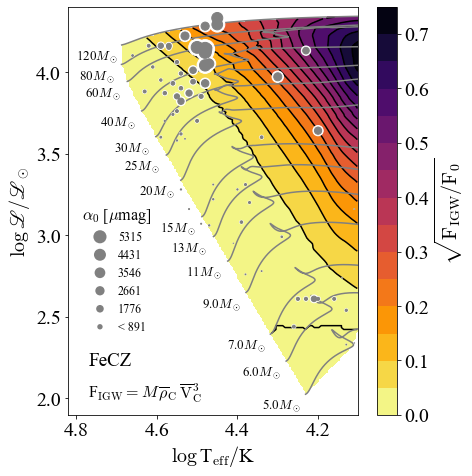

In [236]:
ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ  # mixing_length_alpha*HI_hp_aver/v_HI_aver
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
     
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
  
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*.  It is Max(Fc/F_*)*Mach 
        
      # Calculate F0  
      F0=h.F0_div_omega_c
      F0=(2.0*3.1415)*F0*(1/(turnover_FeCZ))**2.0  # Multiply by 2pi to get N into angular frequency (since omega is angular frequency)
      lstar=lsun*10**logl  
      rstar=rsun*10**h.log_R
        
      fstar = lstar/(4*pi*rstar**2.0)
      
      figw=flux*fstar
      figw_div_f0 = figw/F0
      figw_div_f0=figw_div_f0**0.5  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(figw_div_f0[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z = np.log10(z) 
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    #levels=np.arange(0,1,0.05)
    #levels = insert(levels,0, 0.001)
    ax.contour(xi, yi, zi, 16, colors='k')#,levels=levels)
    cntr1 = ax.contourf(xi, yi, zi, 16, cmap='inferno_r')#,levels=levels) #cmap="YlOrRd")
    
    
     #levels=np.arange(0.05,0.7,0.05)
    #levels = insert(levels,0, 0.0000001)
    #ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    #ax.contour(xi, yi, zi, 12, colors='k') # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r') #cmap="YlOrRd")
    
    
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{{\rm F}_{\rm IGW}/{\rm F}_0}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
        
     ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################    
        
    ax.text(4.77,2.2,'FeCZ',fontsize=19)    
    ax.text(4.77,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.82,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
  #  plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"sqrt_flux_f0_FeCZ_mach_rednoise_nodata.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


## Mach Number

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide


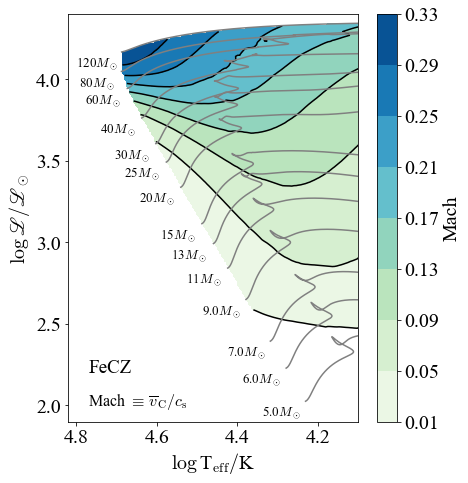

In [237]:
ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ  # mixing_length_alpha*HI_hp_aver/v_HI_aver
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
     
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 

      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      mach_aver=h.mach_FeCZ_aver
      flux=h.FeCZ_Fc_max*mach_FeCZ_aver_ahp   # Multiplied by Max Fc/F*.  It is Max(Fc/F_*)*Mach 
    
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(mach_aver[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z = np.log10(z) 
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    max_level=max(z)
    levels=np.arange(0.01,max_level+0.02,0.04)
    #levels = insert(levels,0, 0.001)
    ax.contour(xi, yi, zi, 12, colors='k',levels=levels)
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='GnBu',levels=levels) #cmap="YlOrRd") PuBu
    
    
    
    #levels = insert(levels,0, 0.0000001)
    #ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    #ax.contour(xi, yi, zi, 12, colors='k') # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r') #cmap="YlOrRd")
    
    
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'Mach')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
       
        
    ax.text(4.77,2.2,'FeCZ',fontsize=19)    
    ax.text(4.77,2.0,r'Mach $ \equiv \,\overline{v}_{\rm C}/c_{\rm s}$',fontsize=16)
    
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
  #  ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.82,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
  #  plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"mach_rednoise_nodata.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


In [238]:
h=mr.MesaData('Z0.02_CORE_BSHUTOFF_LMC/template/LOGS/history.data')

In [239]:
vaver=h.v_FeCZ_aver
mach_max=h.mach_FeCZ_max
mach_aver=h.mach_FeCZ_aver
star_age=h.star_age
mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp
mach_top_cz_core=h.mach_top_cz_core
mach_aver_ahp_core=h.mach_aver_ahp_core
mach_max_core = h.mach_max_core
mach_aver_core = h.mach_aver_core
        

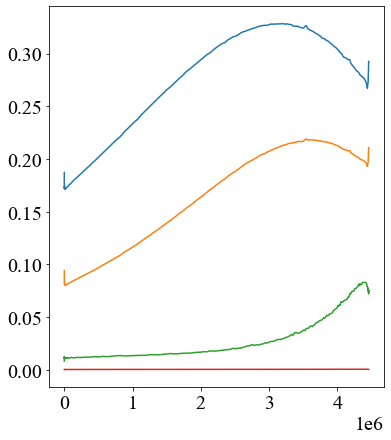

In [240]:
plt.plot(star_age,mach_max)
plt.plot(star_age,mach_aver)
plt.plot(star_age,mach_FeCZ_aver_ahp)
plt.plot(star_age,mach_aver_ahp_core)


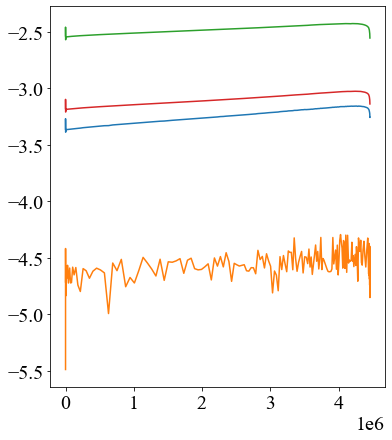

In [241]:
plt.plot(star_age,np.log10(mach_aver_ahp_core))
plt.plot(star_age,np.log10(mach_top_cz_core))
plt.plot(star_age,np.log10(mach_max_core))
plt.plot(star_age,np.log10(mach_aver_core))
 

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide


6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


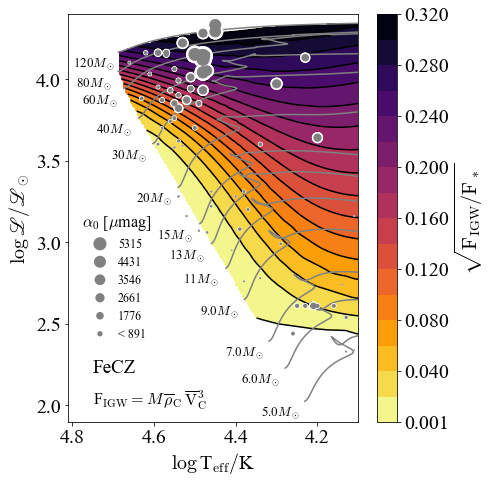

In [242]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
    
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      mach_aver=h.mach_FeCZ_aver               # Convective averave Mach number FeCZ  
      flux=h.FeCZ_Fc_max*mach_aver   # Multiplied by Max Fc/F*
      #flux=flux**0.5  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
 #     tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    z=z**0.5
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    #levels=np.arange(0.05,0.7,0.05)
    #levels = insert(levels,0, 0.0000001)
    
    
    levels=np.arange(0.02,max(z),0.02)
    levels = insert(levels,0, 0.001)
    
    ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    
    
    
    #ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    #ax.contour(xi, yi, zi, 12, colors='k') # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r') #cmap="YlOrRd")
    
    
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{{\rm F}_{\rm IGW}/{\rm F}_*}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
   #     tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
    
     ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
#    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"_sqrt_flux_FeCZ_mach_rednoise.pdf",bbox_inches='tight')

        
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120]
read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide


6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


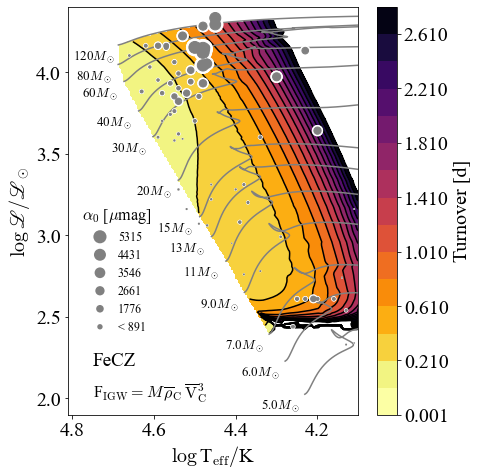

In [243]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
    
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
      #mach_FeCZ_aver_ahp=h.mach_FeCZ_aver_ahp # Convective Mach number top 1Hp of FeCZ
      #mach_aver=h.mach_FeCZ_aver               # Convective averave Mach number FeCZ  
      #flux=h.FeCZ_Fc_max*mach_aver   # Multiplied by Max Fc/F*
      #flux=flux**0.5  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
 #     tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(turnover_FeCZ[zams:]/(24*3600))
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    #levels=np.arange(0.05,0.7,0.05)
    #levels = insert(levels,0, 0.0000001)
    
    
    levels=np.arange(0.01,3,0.2)
    levels = insert(levels,0, 0.001)
    
    ax.contour(xi, yi, zi, 12, colors='k' ,levels=levels)# ,setlims=True
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r' ,levels=levels) #cmap="YlOrRd")
    
    
    
    
    #ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
    
    #ax.contour(xi, yi, zi, 12, colors='k') # ,setlims=True
    #cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r') #cmap="YlOrRd")
    
    
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'Turnover [d]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
   #     tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.75,2.2,'FeCZ',fontsize=19)    
    ax.text(4.75,2.0,r'F$_{\rm IGW} = M\,\overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
    
     ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    
    ax.scatter(logt_data,logl_data,s=alpha0_data/15,c='white',zorder=3)
    ax.scatter(logt_data,logl_data,s=alpha0_data/30,c='gray',zorder=3)
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
#    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"_sqrt_flux_FeCZ_mach_rednoise.pdf",bbox_inches='tight')

        
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120]
read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:89: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:90: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantie

-1.0 120.0
['$\\mathdefault{10}$', '$\\mathdefault{20}$', '$\\mathdefault{30}$', '$\\mathdefault{40}$', '$\\mathdefault{50}$', '$\\mathdefault{60}$', '$\\mathdefault{70}$', '$\\mathdefault{80}$', '$\\mathdefault{90}$', '$\\mathdefault{100}$', '$\\mathdefault{110}$', '$\\mathdefault{120}$']
['$\\mathdefault{120}$', '$\\mathdefault{100}$', '$\\mathdefault{80}$', '$\\mathdefault{60}$', '$\\mathdefault{40}$', '$\\mathdefault{20}$']


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/collections.py:922: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


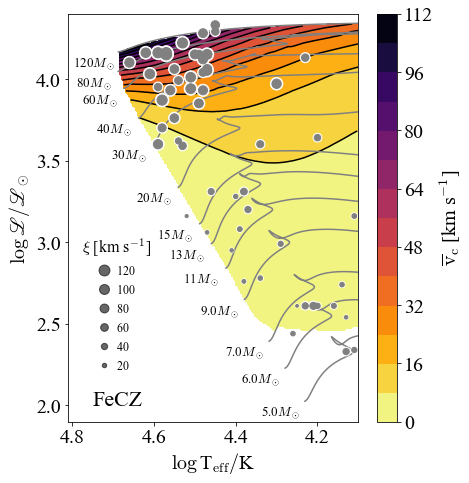

In [244]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
  #    tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_conv_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ [km s$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
       # tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
   
    ax.scatter(logt_data,logl_data,s=vmacro_data*1.8,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=vmacro_data,c='gray',zorder=3)
    print(min(vmacro_data),max(vmacro_data))
    
    
    handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
    print(labels)
    handles=handles[::-2]
    labels=labels[::-2]
    print(labels)
    legend2 = ax.legend(handles, labels,  title=r"$\xi$ [km s$^{-1}$]",frameon=False, 
          fontsize=12,  bbox_to_anchor=(0.02,0.1),
          loc='lower left')
    
    ax.text(4.75,2.0,'FeCZ',fontsize=22)    
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_macroturbulence.pdf",bbox_inches='tight')

read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:92: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:93: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantie

-1.0 120.0
['$\\mathdefault{10}$', '$\\mathdefault{20}$', '$\\mathdefault{30}$', '$\\mathdefault{40}$', '$\\mathdefault{50}$', '$\\mathdefault{60}$', '$\\mathdefault{70}$', '$\\mathdefault{80}$', '$\\mathdefault{90}$', '$\\mathdefault{100}$', '$\\mathdefault{110}$', '$\\mathdefault{120}$']
['$\\mathdefault{120}$', '$\\mathdefault{100}$', '$\\mathdefault{80}$', '$\\mathdefault{60}$', '$\\mathdefault{40}$', '$\\mathdefault{20}$']


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/collections.py:922: RuntimeWarning: invalid value encountered in sqrt
  scale = np.sqrt(self._sizes) * dpi / 72.0 * self._factor


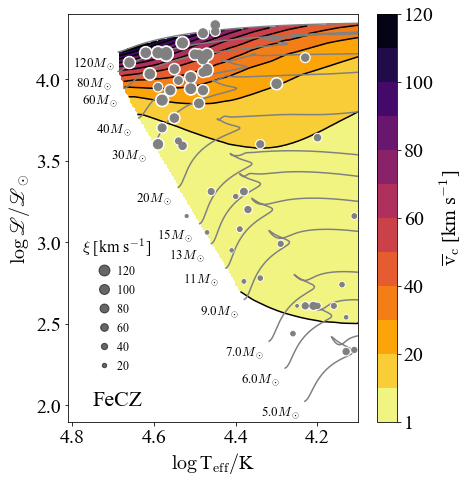

In [245]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
      v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      #max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
  #    tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_conv_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    levels=np.arange(10,121,10)
    levels = insert(levels,0, 1)
    
    ax.contour(xi, yi, zi, 12, colors='k',setlims=True,levels=levels)
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',setlims=True,levels=levels) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ [km s$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
       # tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
   
    ax.scatter(logt_data,logl_data,s=vmacro_data*1.8,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=vmacro_data,c='gray',zorder=3)
    print(min(vmacro_data),max(vmacro_data))
    
    
    handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
    print(labels)
    handles=handles[::-2]
    labels=labels[::-2]
    print(labels)
    legend2 = ax.legend(handles, labels,  title=r"$\xi$ [km s$^{-1}$]",frameon=False, 
          fontsize=12,  bbox_to_anchor=(0.02,0.1),
          loc='lower left')
    
    ax.text(4.75,2.0,'FeCZ',fontsize=22)    
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.81,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_macroturbulence.pdf",bbox_inches='tight')

read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:108: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:109: UserWarning: The following kwargs were not used by contour: 'setlims'


6.269 5315.488
[5315.488      4430.61816667 3545.74833333 2660.8785     1776.00866667
  891.13883333]
[5315, 4431, 3546, 2661, 1776, '< 891']


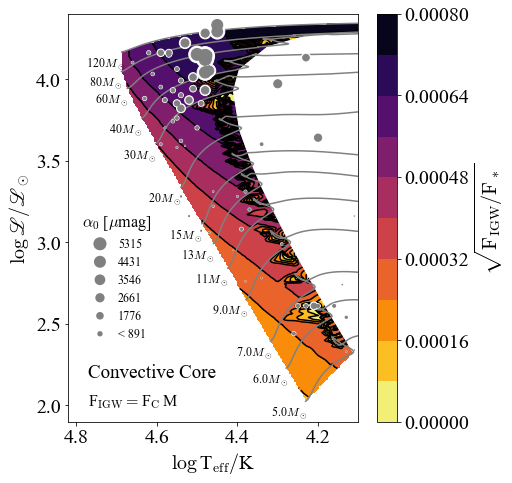

In [246]:
ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
        
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      v_aver_core=h.v_aver_core
      rho_aver_core=h.rho_aver_core
      
      rho_aver_ahp_core=h.rho_aver_ahp_core
      v_aver_ahp_core=h.v_aver_ahp_core  
      mach_aver_ahp_core=h.mach_aver_ahp_core
      
      radius=10**h.log_R 
      stellar_flux= logl*lsun/(4*3.14*(radius*rsun)**2.0)
        
      flux_ahp=rho_aver_ahp_core*v_aver_ahp_core**3.0  # Flux in the top hp of the convective core
      # Divide by the total stellar flux (this shoul be pretty much the Mach number. Check)
      flux_IGW_ahp=flux_ahp*mach_aver_ahp_core/stellar_flux    # Assume IGWs are mostly driven in the top Hp
        
      flux_average=rho_aver_core*v_aver_core**3.0     # Average Flux in the convective core 
      flux_IGW_average=flux_average*mach_aver_ahp_core 
        
      v_aver_core=v_aver_core 
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(mach_aver_ahp_core[zams:])
      #flux_IGW_ahp[tams:]=1  
      #z.append(flux_IGW_ahp[tams:])  
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    #z=z**0.5 
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 10, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 10, cmap='inferno_r',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\sqrt{{\rm F}_{\rm IGW}/{\rm F}_*}$')
    plt.gca().invert_xaxis()
    
   
    dt = 0.04
    dl = -0.09
    
    mask=[]
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=12) # ,verticalalignment='center',rotation='vertical',  
        mask.append([logt[tams],ell[tams]]) # To patch region of interpolation outside tams 
    # Patch contour region outside tams
    # print(mask)    
    patches = []   
    polygon = matplotlib.patches.Polygon(mask, closed=True,fill=True, color='white')
    patches.append(polygon)
    coll = PatchCollection(patches, zorder=2,color='white')
    ax.add_collection(coll) 
    
    ##### SCATTER PLOT ######
    
    norm_factor = 30
    ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor*2,c='white',zorder=3)
    scatter = ax.scatter(logt_data,logl_data,s=alpha0_data/norm_factor,c='gray',zorder=3)
    
    
    
    n_points = 6 # Select how many markers in legend
    vmax=max(alpha0_data)
    vmin=min(alpha0_data)
    print(vmin,vmax)
    delta = (vmax-vmin)/n_points
    scatt_size=np.arange(vmax,vmin,-delta)
    print(scatt_size)
    # scatt_size = scatt_size[::-1]
    
    scatt_label = scatt_size
    scatt_label=np.rint(scatt_label).astype(int) # Round to nearest integer
    scatt_label=scatt_label.tolist()             # Make list so we can add text to labels
    scatt_label[-1]='< '+str(scatt_label[-1])      # Add '<' 100 
    # scatt_size=scatt_size/max_alpha              # Matplotlib seems to renormalize to the max value. This confused me for a bit...
    print(scatt_label)
    
    
    # Fake scatter 
    l1 = ax.scatter([],[], s=scatt_size[0], edgecolors='none',color='gray',label=scatt_label[0])
    l2 = ax.scatter([],[], s=scatt_size[1], edgecolors='none',color='gray',label=scatt_label[1])
    l3 = ax.scatter([],[], s=scatt_size[2], edgecolors='none',color='gray',label=scatt_label[2])
    l4 = ax.scatter([],[], s=scatt_size[3], edgecolors='none',color='gray',label=scatt_label[3])
    l5 = ax.scatter([],[], s=scatt_size[4], edgecolors='none',color='gray',label=scatt_label[4])
    l6 = ax.scatter([],[], s=scatt_size[5], edgecolors='none',color='gray',label=scatt_label[4])
    
     # And finally the legend (Matplotlib def needs better handling of scatter plot legends of this type)
    leg = plt.legend([l1,l2, l3, l4, l5, l6], scatt_label, frameon=False, 
          fontsize=12,handlelength=2,   bbox_to_anchor=(0.02,0.18),
          loc='lower left', title=r"$\alpha_0$ [$\mu$mag]", markerscale=0.18) # 0.18 determined by making larger symbol match with plot. Still not sure how to do this properly...
    
    ############################
    
    
    ax.text(4.77,2.17,'Convective Core',fontsize=19)    
    ax.text(4.77,2.0,r'F$_{\rm IGW} = $F$_{\rm C}\, $M ',fontsize=16)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
   # ax.text(4.77,2.13,'Convective Core',fontsize=18)    
   # ax.text(4.77,2.0,r'F$_{\rm IGW} = $F$_{\rm C}\, $M ',fontsize=17)
    
    ax.set_xlim([4.82,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
 #   plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"mach_core_rednoise_data.pdf",bbox_inches='tight')

        

read_models(DIR,mods)


# Grid at Z=0.002


In [247]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/15140/Z0.002/' # 30,80, 100,120
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,50,60,80,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,18,25,40,60,80,120]

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:89: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:90: UserWarning: The following kwargs were not used by contour: 'setlims'


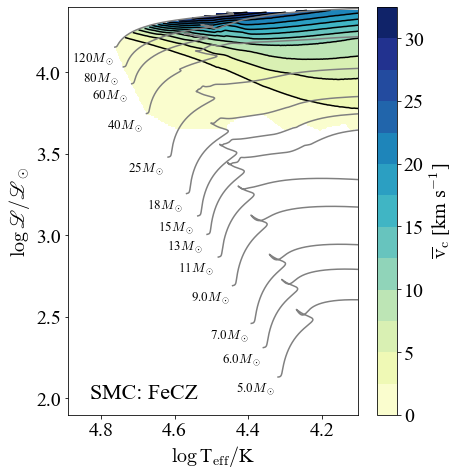

In [248]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
  #    tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_conv_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='YlGnBu',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ [km s$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
      #  tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
   
    
    ax.text(4.83,2.0,'SMC: FeCZ',fontsize=22)    
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.89,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_macroturbulence_SMC.pdf",bbox_inches='tight')

read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:47: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:49: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:50: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:48: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:81: RuntimeWarning: divide by zero encountered in log10
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:277: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*

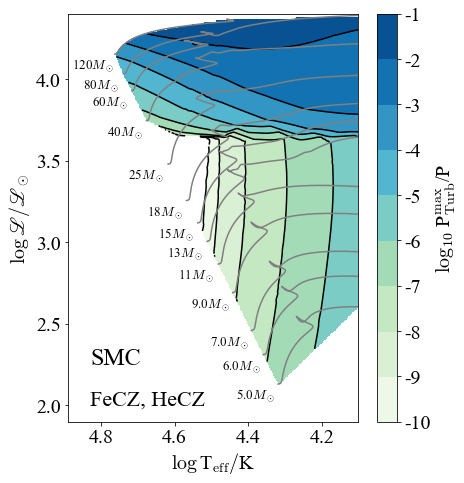

In [249]:
ell_sun=(5777)**4.0/(274*100)  

plt.rcParams["contour.negative_linestyle"]='solid'
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver 
    
      FeCZ_p_turb_over_p=h.FeCZ_p_turb_over_p
      HeII_p_turb_over_p=h.HeII_p_turb_over_p
      HeI_p_turb_over_p=h.HeI_p_turb_over_p
      HI_p_turb_over_p=h.HI_p_turb_over_p  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      max_turb_pressure=np.maximum.reduce([FeCZ_p_turb_over_p,HeII_p_turb_over_p,HeI_p_turb_over_p,HI_p_turb_over_p,]) 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_turb_pressure[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
    z=np.log10(z)
    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    levels=np.arange(-10,0,1)
    #levels = insert(levels,0, 1)
    
    ax.contour(xi, yi, zi, 10,levels=levels, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 10,levels=levels, cmap='GnBu',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax,format='%.0f').ax.set_ylabel(r'$\log_{10}$ P$^{\rm max}_{\rm Turb}$/P')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
  
    ax.text(4.83,2.25,'SMC',fontsize=24)
    ax.text(4.83,2.0,'FeCZ, HeCZ',fontsize=22)
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.89,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_turbulentpressure_SMC.pdf",bbox_inches='tight')

read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:54: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:277: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:278: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


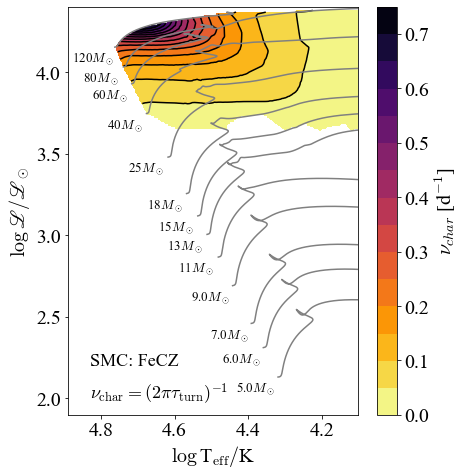

In [250]:

ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      z.append(turnover_FeCZ[zams:]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
    z=z/1.6 # Correct for Mixing Length Alpha (we calculate turnover as alpha H / vel)
    
    z=(1/(z*2*3.14/86400))  # in nu=(2\ pi Tau)^-1   in Bowman et al.      (d^-1 86400_
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ [d$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.text(4.83,2.0,r'$\nu_{\rm char} = (2 \pi \tau_{\rm turn})^{-1}$ ',fontsize=18) # 
    ax.text(4.83,2.2,'SMC: FeCZ',fontsize=18)
   # ax.scatter(logt_data,logl_data,s=nuchar_data*18,c='white',zorder=3)
   # ax.scatter(logt_data,logl_data,s=nuchar_data*10,c='gray',zorder=3)
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.89,4.1])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_FeCZ_SMC.pdf",bbox_inches='tight')

    
read_models(DIR,mods)

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:38: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: invalid value encountered in true_divide


[1.0e-08 1.0e-02 6.0e-02 1.1e-01 1.6e-01 2.1e-01]


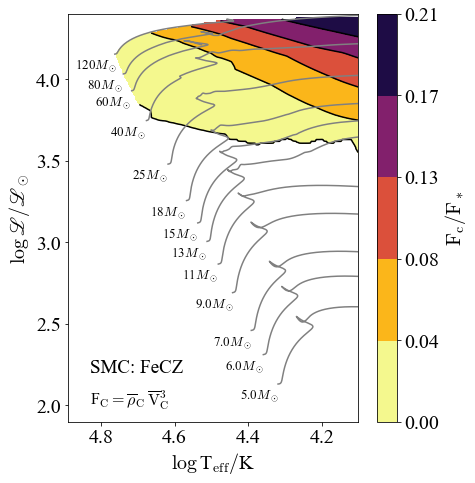

In [251]:


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   
      flux=h.FeCZ_Fc_max  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=z**0.5


    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    maxf=max(z)
    levels=np.arange(0.01,maxf+0.05,0.05)
    levels = insert(levels,0, 0.00000001)
    print(levels)
    
    ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
   
    cbar = fig.colorbar(cntr1, ax=ax)
    cbar.ax.set_ylabel(r'${\rm F}_{\rm c}/{\rm F}_*$')
    
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.gca().invert_xaxis()
    
   
    dt = 0.05
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.83,2.2,'SMC: FeCZ',fontsize=19)    
    ax.text(4.83,2.0,r'F$_{\rm C} = \overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
   
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.89,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
#    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"flux_FeCZ_rednoise_SMC.pdf",bbox_inches='tight')

#hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120] 
read_models(DIR,mods)


# Grid at Z=0.006

In [262]:
DIR = '/Users/mcantiello/Dropbox (Personal)/work/red_noise/15140/Z0.006/'
mods = [5.0, 5.2, 5.4 ,5.6 ,5.8, 6.0, 7.0,8.0,9.0,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,40,50,60,80,120]# ,100,120]
hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120]#,120]

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:43: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:44: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:42: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:89: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:90: UserWarning: The following kwargs were not used by contour: 'setlims'


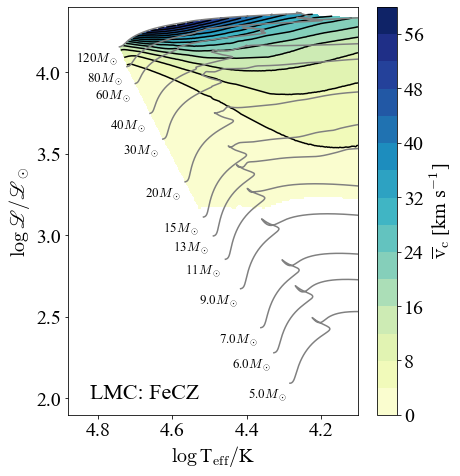

In [263]:
ell_sun=(5777)**4.0/(274*100)  

def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
  #    tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_conv_velocity[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>

    z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='YlGnBu',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\overline{\rm v}_{\rm c}$ [km s$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
      #  tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
    #ax.text(4.78,2.1,r'v$_{\rm s}$ = $\bar{\rm v}_{\rm FeCZ} \, (M \rho_{\rm FeCZ}/\rho_{\rm s})^{1/2}$',fontsize=14)
   
 #   ax.scatter(logt_data,logl_data,s=vmacro_data*1.8,c='white',zorder=3)
 #  scatter = ax.scatter(logt_data,logl_data,s=vmacro_data,c='gray',zorder=3)
 #   print(min(vmacro_data),max(vmacro_data))
    
    
 #   handles, labels = scatter.legend_elements(prop="sizes", alpha=0.6)
 #   print(labels)
 #   handles=handles[::-2]
 #   labels=labels[::-2]
 #   print(labels)
 #   legend2 = ax.legend(handles, labels,  title=r"$\xi$ [km s$^{-1}$]",frameon=False, 
 #         fontsize=12,  bbox_to_anchor=(0.02,0.1),
 #         loc='lower left')
    
    ax.text(4.82,2.0,'LMC: FeCZ',fontsize=22)    
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.88,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_macroturbulence_LMC.pdf",bbox_inches='tight')

read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:45: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:47: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:48: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:46: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:96: UserWarning: The following kwargs were not used by contour: 'setlims'
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:97: UserWarning: The following kwargs were not used by contour: 'setlims'


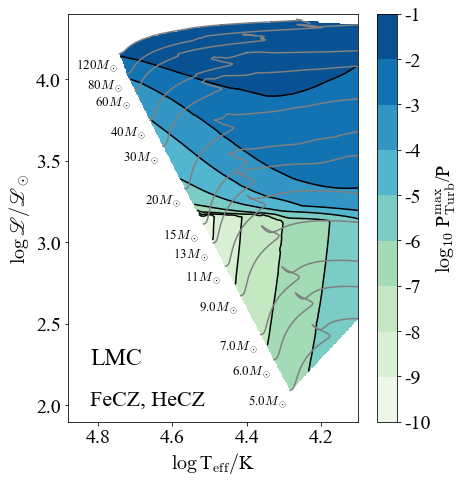

In [264]:

plt.rcParams["contour.negative_linestyle"]='solid'
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver 
    
      FeCZ_p_turb_over_p=h.FeCZ_p_turb_over_p
      HeII_p_turb_over_p=h.HeII_p_turb_over_p
      HeI_p_turb_over_p=h.HeI_p_turb_over_p
      HI_p_turb_over_p=h.HI_p_turb_over_p  
      #v_FeCZ_aver=h.v_FeCZ_aver
    
      alpha_mlt=1.5 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
      max_turb_pressure=np.maximum.reduce([FeCZ_p_turb_over_p,HeII_p_turb_over_p,HeI_p_turb_over_p,HI_p_turb_over_p,]) 
      #max_conv_velocity=v_FeCZ_aver 
   #   print(max_conv_velocity)
#      max_surf_velocity= np.maximum.reduce([v_HeII_surf,v_HeI_surf,v_HI_surf])
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      #tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(max_turb_pressure[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
    z=np.log10(z)
    #z=(z/1e5)  # in km/s
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    levels=np.arange(-10,0,1)
    
    ax.contour(xi, yi, zi, 10, levels=levels, colors='k',setlims=True)
    cntr1 = ax.contourf(xi, yi, zi, 10, levels=levels, cmap='GnBu',setlims=True) #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax,format='%.0f').ax.set_ylabel(r'$\log_{10}$ P$^{\rm max}_{\rm Turb}$/P')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        #tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
  
    ax.text(4.82,2.25,'LMC',fontsize=24)
    ax.text(4.82,2.0,'FeCZ, HeCZ',fontsize=22)
    # ax.text(4.75,2.13,r'Macroturbulence',fontsize=17)
    
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.88,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Macroturbulence')
    plt.savefig(FIGURES+"vc_FeCZ_turbulentpressure_LMC.pdf",bbox_inches='tight')

read_models(DIR,mods)


/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:54: RuntimeWarning: divide by zero encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:277: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 1]*y +
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/matplotlib/tri/triinterpolate.py:278: RuntimeWarning: invalid value encountered in add
  self._plane_coefficients[tri_index, 2])


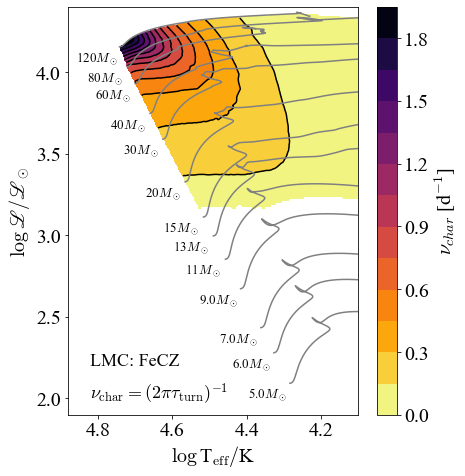

In [265]:

ell_sun=(5777)**4.0/(274*100)  
def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
         
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver  
      
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
    
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(logt[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      z.append(turnover_FeCZ[zams:]) 
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=((1/z)*1e6)/1.6 # in microHz (the 1.6 is to correct for alpha_mixing lenght, as I calculated turnover timescales as alpha*<Hp>/<vconv>
    z=z/1.6 # Correct for Mixing Length Alpha (we calculate turnover as alpha H / vel)
    
    z=(1/(z*2*3.14/86400))  # in nu=(2\ pi Tau)^-1   in Bowman et al.      (d^-1 86400_
    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    ax.contour(xi, yi, zi, 14, colors='k')
    cntr1 = ax.contourf(xi, yi, zi, 14, cmap='inferno_r') #cmap="YlOrRd")
    # fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ ($\mu$Hz)')
    fig.colorbar(cntr1, ax=ax).ax.set_ylabel(r'$\nu_{char}$ [d$^{-1}$]')
    plt.gca().invert_xaxis()
    
   
    dt = 0.06
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
        
 #   ax.text(4.7,2.8,r'$\nu_{char} := \tau_{turn}^{-1}$ = $\bar{v}_{c}/\bar{H}_{P}$',fontsize=13)
 #   ax.text(4.7,3.3,'FeCZ',fontsize=15)
    ax.text(4.82,2.0,r'$\nu_{\rm char} = (2 \pi \tau_{\rm turn})^{-1}$ ',fontsize=18) # 
    ax.text(4.82,2.2,'LMC: FeCZ',fontsize=18)
   # ax.scatter(logt_data,logl_data,s=nuchar_data*18,c='white',zorder=3)
   # ax.scatter(logt_data,logl_data,s=nuchar_data*10,c='gray',zorder=3)
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    #ax.set_xlim([4.76,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_xlim([4.88,4.1])
    ax.set_ylim([1.9,4.4])
    
 #   plt.title(r'Characteristic Frequency ($\nu_{\rm char}$)')
    plt.savefig(FIGURES+"freq_FeCZ_LMC.pdf",bbox_inches='tight')

    
read_models(DIR,mods)

/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:38: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:40: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:41: RuntimeWarning: invalid value encountered in true_divide
/Users/mcantiello/anaconda/envs/matplotlib_build/lib/python3.7/site-packages/ipykernel_launcher.py:39: RuntimeWarning: invalid value encountered in true_divide


[1.0e-08 1.0e-02 6.0e-02 1.1e-01 1.6e-01 2.1e-01 2.6e-01 3.1e-01 3.6e-01]


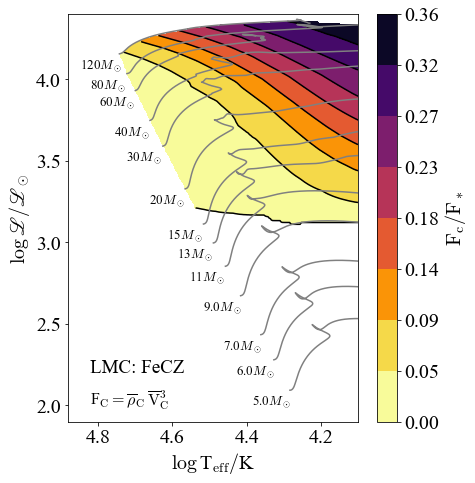

In [266]:


def read_models(location,lis):
    x = []
    y = []
    z = []

    k = 0

    zhI = []
    zheI = []
    zheII = []
    zFeCZ = []
    lzams = []
    tzams = []
    gzams = []

    for i in lis:
      h=mr.MesaData(location+str(i)+'/LOGS/history.data')
      model = h.model_number 
      logl = h.log_L
      logg = h.log_g 
      loglh=h.log_LH 
      center_h1 = h.center_h1 
      logt= h.log_Teff 
      v_FeCZ_surf=h.v_FeCZ_surf 
      v_HeII_surf=h.v_HeII_surf   
      v_HeI_surf=h.v_HeI_surf
      v_HI_surf=h.v_HI_surf  
      turnover_FeCZ=h.turnover_FeCZ
      turnover_HeII=h.turnover_HeII
      turnover_HeI=h.turnover_HeI
      turnover_HI=h.turnover_HI
      FeCZ_hp_aver=h.FeCZ_hp_aver
      HeII_hp_aver=h.HeII_hp_aver
      HeI_hp_aver=h.HeI_hp_aver
      HI_hp_aver=h.HI_hp_aver  
    
      alpha_mlt=1.6 
      vcFeCZ=alpha_mlt*FeCZ_hp_aver/turnover_FeCZ  
      vcHeII=alpha_mlt*HeII_hp_aver/turnover_HeII  
      vcHeI=alpha_mlt*HeI_hp_aver/turnover_HeI  
      vcHI=alpha_mlt*HI_hp_aver/turnover_HI 
      
      max_surf_velocity= np.maximum.reduce([v_FeCZ_surf,v_HeII_surf,v_HeI_surf,v_HI_surf])
      max_conv_velocity=np.maximum.reduce([vcFeCZ])# ,vcHeII])  # Prob with NaNs 
   
      flux=h.FeCZ_Fc_max  
    
      ell = (10**logt)**4.0/(10**logg)
      ell=np.log10(ell/ell_sun)  
      
      ncz=h.subsurface_convective_regions 
      zams=find_zams(logl,loglh,model)
      tams=find_tams(center_h1,model)
      zams=find_h(0.001,center_h1,model)
        
      # Create Lists  
      lzams.append(ell[zams])
      gzams.append(logg[zams])
      tzams.append(ell[zams])
      x.append(logt[zams:])
      y.append(ell[zams:])
      #z.append(v_FeCZ_surf[zams:]) 
      z.append(flux[zams:])
      

    x=array(list(flatten(x)))
    y=array(list(flatten(y)))
    z=array(list(flatten(z)))#/1e5 # (in km/s)
    #z=z**0.5


    
    fig = plt.figure()
    ax = fig.add_axes([0.13, 0.12, 0.84, 0.81])
    
    numcols, numrows = 200, 200
    xi = np.linspace(x.min(), x.max(), numcols)
    yi = np.linspace(y.min(), y.max(), numrows)
    
    triang = tri.Triangulation(x,y)
    interpolator = tri.LinearTriInterpolator(triang, z)
    Xi, Yi = np.meshgrid(xi, yi)
    zi = interpolator(Xi, Yi)
    
    maxf=max(z)
    levels=np.arange(0.01,maxf+0.05,0.05)
    levels = insert(levels,0, 0.00000001)
    print(levels)
    
    ax.contour(xi, yi, zi, 12, colors='k',levels=levels) # ,setlims=True
    cntr1 = ax.contourf(xi, yi, zi, 12, cmap='inferno_r',levels=levels) #cmap="YlOrRd")
   
    cbar = fig.colorbar(cntr1, ax=ax)
    cbar.ax.set_ylabel(r'${\rm F}_{\rm c}/{\rm F}_*$')
    
    cbar.ax.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    plt.gca().invert_xaxis()
    
   
    dt = 0.05
    dl = -0.09
    
    
    for i in hrdlines:
        h=mr.MesaData(DIR+str(i)+'/LOGS/history.data')
        model = h.model_number 
        logl = h.log_L
        logg = h.log_g 
        loglh=h.log_LH 
        center_h1 = h.center_h1 
        logt= h.log_Teff 
        zams=find_zams(logl,loglh,model)
        tams=find_tams(center_h1,model)
        zams=find_h(0.001,center_h1,model)
        ell = (10**logt)**4.0/(10**logg)
        ell=np.log10(ell/ell_sun)  
        plt.plot(logt[zams:],ell[zams:],c='gray',alpha=1.0)
        ax.text(logt[zams]+dt,ell[zams]+dl,str(i)+r'$M_\odot$',ha='center',fontsize=13) # ,verticalalignment='center',rotation='vertical',  
        
    ax.text(4.82,2.2,'LMC: FeCZ',fontsize=19)    
    ax.text(4.82,2.0,r'F$_{\rm C} = \overline{\rho}_{\rm C}\,\overline{\rm V}_{\rm C}^3$',fontsize=16)
    
   
    
    ax.set_xlabel(logteff)
    ax.set_ylabel(r'$\log\, \mathscr{L} / \mathscr{L}_\odot$')
    ax.set_xlim([4.88,4.1])
    #ax.set_ylim([2.5,6.25])
    ax.set_ylim([1.9,4.4])
#    plt.title(r'Photometric Amplitude $\alpha_0$')
    plt.savefig(FIGURES+"flux_FeCZ_rednoise_LMC.pdf",bbox_inches='tight')

#hrdlines = [5.0,6.0,7.0,9.0,11,13,15,20,30,40,60,80,120] 
read_models(DIR,mods)
